# Class 03 — Observational Studies
**DSC 215 · Statistical Critical Thinking & Experimental Design · UCSD**

---

The slides are conceptual — this notebook *demonstrates* what they assert: simulating all four cells of the causation/generalizability matrix, building confounders from scratch, applying correction strategies, and critically reading real observational claims.

**Contents:**
1. [Setup](#1)
2. [The 2×2 Matrix: Causation × Generalizability](#2)
3. [Confounding — Built from Scratch](#3)
4. [Confounder Correction Strategies](#4)
5. [Generalizability — How Sampling Distorts Conclusions](#5)
6. [Critical Reading of Real Observational Claims](#6)

---

<a id='1'></a>
## 1. Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

np.random.seed(42)
plt.rcParams.update({'figure.dpi':120,'font.family':'DejaVu Sans',
                     'axes.spines.top':False,'axes.spines.right':False,
                     'axes.titlesize':13,'axes.labelsize':11})
BLUE='#2563EB'; RED='#DC2626'; GREEN='#16A34A'; ORANGE='#D97706'; GRAY='#6B7280'
print('Ready.')

Ready.


<a id='2'></a>
## 2. The 2×2 Matrix: Causation × Generalizability

The slides present this framework: **Random assignment** enables causal inference; **Random sampling** enables generalizability. You need both for the ideal experiment. We simulate all four cells numerically.

In [4]:
N_POP = 100000
TRUE_ATE = 3.0
rng = np.random.default_rng(0)
age      = rng.normal(50, 15, N_POP)
baseline = 0.1 * age + rng.normal(0, 2, N_POP)

def run_cell(random_assign, random_sample, n=500, label=''):
    if random_sample:
        idx = rng.choice(N_POP, n, replace=False)
    else:
        p_select = np.exp(0.03 * (age - 50))
        p_select /= p_select.sum()
        idx = rng.choice(N_POP, n, replace=False, p=p_select)
    age_s = age[idx]; base_s = baseline[idx]
    if random_assign:
        T = rng.integers(0, 2, n)
    else:
        p_treat = 1 / (1 + np.exp(0.05 * (age_s - 50)))
        T = rng.binomial(1, p_treat)
    Y = base_s + TRUE_ATE * T + rng.normal(0, 2, n)
    ate_est  = Y[T==1].mean() - Y[T==0].mean()
    age_bias = age_s.mean() - age.mean()
    print(f"  {label}")
    print(f"    Sample mean age: {age_s.mean():.1f}  (pop: {age.mean():.1f}, bias: {age_bias:+.1f})")
    print(f"    Estimated ATE:   {ate_est:.2f}  (True: {TRUE_ATE})")
    print(f"    ATE bias:        {ate_est - TRUE_ATE:+.2f}")
    print()
    return ate_est, age_s.mean()

print("=== 2x2 MATRIX SIMULATION ===\n")
print("Cell 1: Random Assignment + Random Sampling  (IDEAL EXPERIMENT)")
r1, a1 = run_cell(True,  True,  label="[Random assign, Random sample]")
print("Cell 2: Random Assignment + No Random Sampling  (MOST EXPERIMENTS)")
r2, a2 = run_cell(True,  False, label="[Random assign, Convenience sample]")
print("Cell 3: No Random Assignment + Random Sampling  (MOST OBS. STUDIES)")
r3, a3 = run_cell(False, True,  label="[Self-selection, Random sample]")
print("Cell 4: No Random Assignment + No Random Sampling  (BAD OBS. STUDY)")
r4, a4 = run_cell(False, False, label="[Self-selection, Convenience sample]")

=== 2x2 MATRIX SIMULATION ===

Cell 1: Random Assignment + Random Sampling  (IDEAL EXPERIMENT)
  [Random assign, Random sample]
    Sample mean age: 51.2  (pop: 50.0, bias: +1.2)
    Estimated ATE:   3.07  (True: 3.0)
    ATE bias:        +0.07

Cell 2: Random Assignment + No Random Sampling  (MOST EXPERIMENTS)
  [Random assign, Convenience sample]
    Sample mean age: 55.1  (pop: 50.0, bias: +5.1)
    Estimated ATE:   3.32  (True: 3.0)
    ATE bias:        +0.32

Cell 3: No Random Assignment + Random Sampling  (MOST OBS. STUDIES)
  [Self-selection, Random sample]
    Sample mean age: 49.4  (pop: 50.0, bias: -0.6)
    Estimated ATE:   2.46  (True: 3.0)
    ATE bias:        -0.54

Cell 4: No Random Assignment + No Random Sampling  (BAD OBS. STUDY)
  [Self-selection, Convenience sample]
    Sample mean age: 56.7  (pop: 50.0, bias: +6.7)
    Estimated ATE:   1.87  (True: 3.0)
    ATE bias:        -1.13



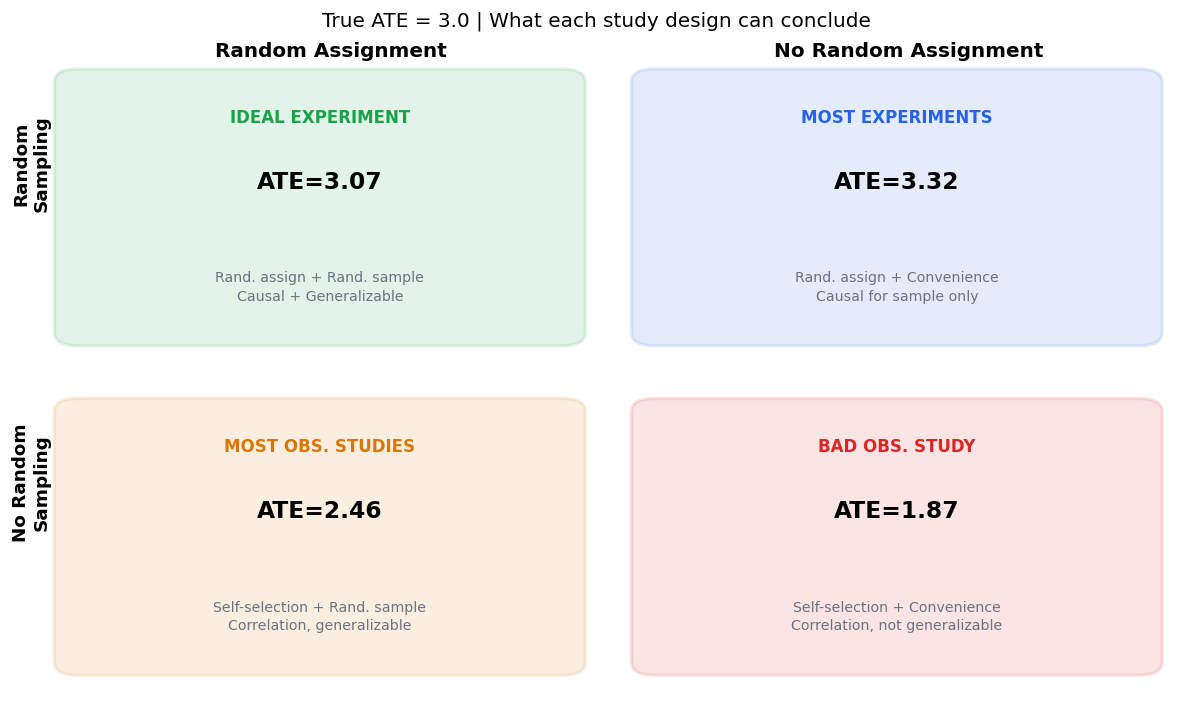

Saved.


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
cells = [
    (0.05, 0.55, "IDEAL EXPERIMENT",   f"ATE={r1:.2f}", GREEN,
     "Rand. assign + Rand. sample\nCausal + Generalizable"),
    (0.55, 0.55, "MOST EXPERIMENTS",   f"ATE={r2:.2f}", BLUE,
     "Rand. assign + Convenience\nCausal for sample only"),
    (0.05, 0.05, "MOST OBS. STUDIES",  f"ATE={r3:.2f}", ORANGE,
     "Self-selection + Rand. sample\nCorrelation, generalizable"),
    (0.55, 0.05, "BAD OBS. STUDY",     f"ATE={r4:.2f}", RED,
     "Self-selection + Convenience\nCorrelation, not generalizable"),
]
for x, y, title, result, col, desc in cells:
    rect = mpatches.FancyBboxPatch((x, y), 0.42, 0.38,
        boxstyle="round,pad=0.02", facecolor=col, alpha=0.12,
        edgecolor=col, linewidth=2, transform=ax.transAxes)
    ax.add_patch(rect)
    ax.text(x+0.21, y+0.32, title,  ha='center', fontsize=10, fontweight='bold',
            color=col, transform=ax.transAxes)
    ax.text(x+0.21, y+0.22, result, ha='center', fontsize=14, fontweight='bold',
            transform=ax.transAxes)
    ax.text(x+0.21, y+0.05, desc,   ha='center', fontsize=8.5, color=GRAY,
            transform=ax.transAxes, linespacing=1.4)
ax.text(0.27, 0.97, 'Random Assignment',    ha='center', fontsize=12, fontweight='bold', transform=ax.transAxes)
ax.text(0.77, 0.97, 'No Random Assignment', ha='center', fontsize=12, fontweight='bold', transform=ax.transAxes)
ax.text(0.01, 0.74, 'Random\nSampling',    ha='center', fontsize=11, fontweight='bold', transform=ax.transAxes, rotation=90)
ax.text(0.01, 0.24, 'No Random\nSampling', ha='center', fontsize=11, fontweight='bold', transform=ax.transAxes, rotation=90)
ax.set_title(f'True ATE = {TRUE_ATE} | What each study design can conclude', fontsize=12)
plt.tight_layout()
plt.savefig('figures/01_2x2_matrix.png', bbox_inches='tight')
plt.show(); print('Saved.')

<a id='3'></a>
## 3. Confounding — Built from Scratch

A confounder $Z$ causes both $X$ (predictor) and $Y$ (response), creating a spurious association. **Slides example:** Ice cream sales and drowning deaths — both caused by summer heat. We build the data-generating process explicitly so we can see exactly what goes wrong.

In [6]:
n = 2000
season    = np.random.binomial(1, 0.5, n)
ice_cream = 10*season + np.random.normal(0, 2, n)
drowning  =  5*season + np.random.normal(0, 1.5, n)
r_naive,  p_naive  = stats.pearsonr(ice_cream, drowning)
r_summer, _        = stats.pearsonr(ice_cream[season==1], drowning[season==1])
r_winter, _        = stats.pearsonr(ice_cream[season==0], drowning[season==0])
print(f"Naive (ignoring season):         r = {r_naive:.3f}, p = {p_naive:.2e}")
print(f"Summer only (confounder fixed):  r = {r_summer:.3f}")
print(f"Winter only (confounder fixed):  r = {r_winter:.3f}")
print("Association disappears once we control for the confounder.")

Naive (ignoring season):         r = 0.794, p = 0.00e+00
Summer only (confounder fixed):  r = -0.019
Winter only (confounder fixed):  r = 0.008
Association disappears once we control for the confounder.


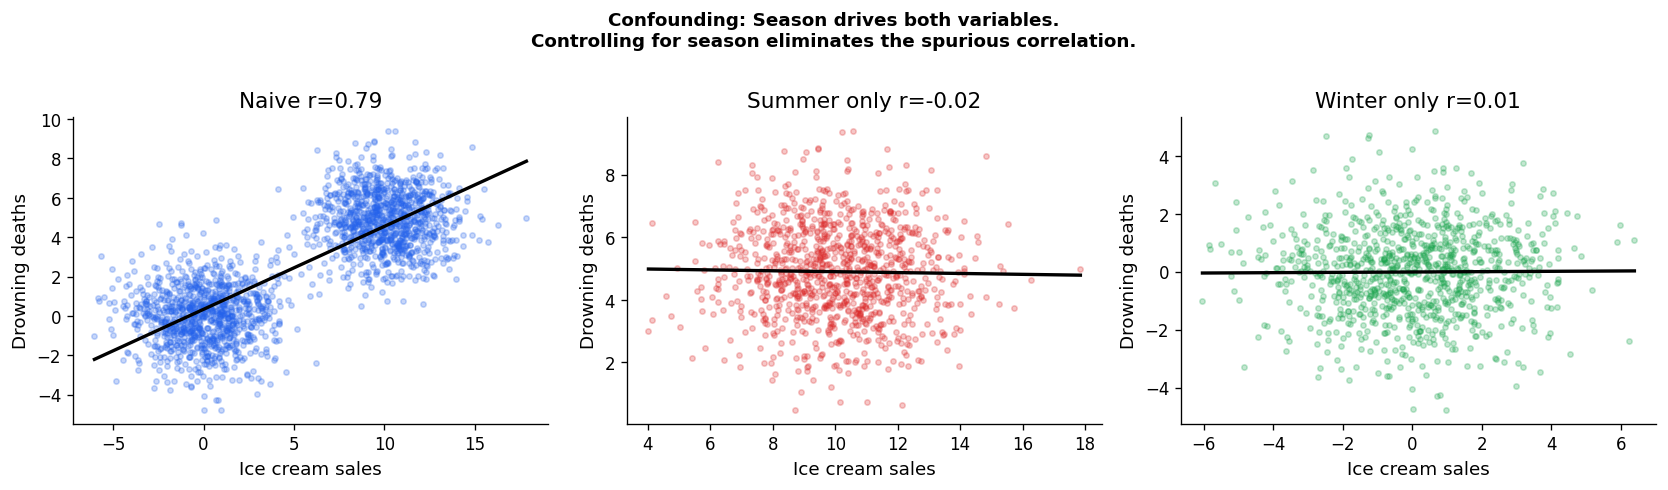

Saved.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (mask, title, col) in zip(axes, [
    (np.ones(n,bool), f'Naive r={r_naive:.2f}', BLUE),
    (season==1, f'Summer only r={r_summer:.2f}', RED),
    (season==0, f'Winter only r={r_winter:.2f}', GREEN),
]):
    ax.scatter(ice_cream[mask], drowning[mask], alpha=0.25, s=10, color=col)
    m, b = np.polyfit(ice_cream[mask], drowning[mask], 1)
    xr = np.linspace(ice_cream[mask].min(), ice_cream[mask].max(), 100)
    ax.plot(xr, m*xr+b, 'k-', lw=2)
    ax.set_title(title); ax.set_xlabel('Ice cream sales'); ax.set_ylabel('Drowning deaths')
plt.suptitle('Confounding: Season drives both variables.\nControlling for season eliminates the spurious correlation.',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/02_confounding.png', bbox_inches='tight')
plt.show(); print('Saved.')

<a id='4'></a>
## 4. Confounder Correction Strategies

The slides mention three approaches — stratification, regression, matching. We apply all three and compare their effectiveness. **Key limitation:** all require the confounder to be *measured*.

In [8]:
np.random.seed(7)
n2      = 1000
age2    = np.random.normal(50, 12, n2)
p_ex    = 1 / (1 + np.exp(0.05*(age2 - 50)))
exercise= np.random.binomial(1, p_ex)
TRUE_FX = -5.0
bp      = TRUE_FX*exercise + 0.3*(age2-50) + np.random.normal(0, 5, n2)

naive_est = bp[exercise==1].mean() - bp[exercise==0].mean()

X_reg = np.column_stack([exercise, age2, np.ones(n2)])
coef, *_ = np.linalg.lstsq(X_reg, bp, rcond=None)
reg_est = coef[0]

age_q = pd.qcut(age2, q=4, labels=False)
strat_ests = []
for q in range(4):
    mask = age_q==q
    if exercise[mask].sum()>5 and (~exercise[mask].astype(bool)).sum()>5:
        strat_ests.append(bp[mask&(exercise==1)].mean() - bp[mask&(exercise==0)].mean())
strat_est = np.mean(strat_ests)

treated_idx = np.where(exercise==1)[0]
control_idx = np.where(exercise==0)[0]
matched_diffs = []
for ti in treated_idx:
    dists = np.abs(age2[control_idx] - age2[ti])
    best  = control_idx[np.argmin(dists)]
    matched_diffs.append(bp[ti] - bp[best])
match_est = np.mean(matched_diffs)

print(f"True effect:           {TRUE_FX:.2f} mmHg")
print(f"Naive (no correction): {naive_est:.2f} mmHg  <- biased")
print(f"Regression adjustment: {reg_est:.2f} mmHg")
print(f"Stratification:        {strat_est:.2f} mmHg")
print(f"Matching:              {match_est:.2f} mmHg")

True effect:           -5.00 mmHg
Naive (no correction): -6.87 mmHg  <- biased
Regression adjustment: -4.78 mmHg
Stratification:        -5.09 mmHg
Matching:              -5.15 mmHg


<a id='5'></a>
## 5. Generalizability — How Sampling Distorts Conclusions

Even a correctly estimated causal effect may not generalize if the sample is not representative of the target population. This is the external validity problem from Class 01.

In [9]:
N3 = 50000
age3   = np.random.normal(45, 18, N3)
cate3  = 1.0 + 0.05*(age3-45)
true_ate_pop = cate3.mean()

def est_ate(n, age_lo=None, age_hi=None, seed=0):
    rng_s = np.random.default_rng(seed)
    if age_lo is not None:
        mask = (age3>=age_lo)&(age3<=age_hi)
        idx  = rng_s.choice(np.where(mask)[0], min(n,mask.sum()), replace=False)
    else:
        idx = rng_s.choice(N3, n, replace=False)
    T = rng_s.integers(0,2,len(idx))
    Y = cate3[idx]*T + 0.1*age3[idx] + rng_s.normal(0,2,len(idx))
    return Y[T==1].mean()-Y[T==0].mean(), age3[idx].mean()

ate_rep,   age_rep   = est_ate(500)
ate_young, age_young = est_ate(500, 18, 35)
ate_old,   age_old   = est_ate(500, 65, 90)

print(f"True population ATE:       {true_ate_pop:.2f}")
print(f"Representative sample:     ATE={ate_rep:.2f}  (mean age {age_rep:.0f})")
print(f"Young adult sample (18-35):ATE={ate_young:.2f}  (mean age {age_young:.0f})  <- drug looks weak")
print(f"Elderly sample (65-90):    ATE={ate_old:.2f}  (mean age {age_old:.0f})  <- drug looks strong")
print()
print("Reporting any single estimate as THE drug effect without noting the sample is misleading.")

True population ATE:       1.00
Representative sample:     ATE=0.98  (mean age 45)
Young adult sample (18-35):ATE=0.10  (mean age 28)  <- drug looks weak
Elderly sample (65-90):    ATE=2.40  (mean age 73)  <- drug looks strong

Reporting any single estimate as THE drug effect without noting the sample is misleading.


<a id='6'></a>
## 6. Critical Reading of Real Observational Claims

We apply a structured critique to each study mentioned in the slides, using the framework: What are the confounders? Is reverse causation plausible? Can we generalize?

In [10]:
claims = pd.DataFrame([
    {'Study':'Lane et al. BMJ 2024',
     'Claim':'Ultra-processed food +48-53pct anxiety',
     'Confounders':'SES, baseline mental health, stress, sleep',
     'Reverse causation?':'YES - anxious people may eat worse',
     'Verdict':'Suggestive, not causal'},
    {'Study':'Perlis et al. JAMA 2026',
     'Claim':'Daily AI use +30pct depression',
     'Confounders':'Social isolation, age, employment',
     'Reverse causation?':'YES - depressed seek AI companionship',
     'Verdict':'Direction of effect unclear'},
    {'Study':'Pilfold et al. Nature Comm 2024',
     'Claim':'Polar bears lose 1 kg/day on land',
     'Confounders':'Year, location, food availability',
     'Reverse causation?':'No',
     'Verdict':'Descriptive, well-supported'},
    {'Study':'Barnola et al. Nature 1987',
     'Claim':'CO2 and temperature correlated over 160k years',
     'Confounders':'Orbital cycles, volcanism',
     'Reverse causation?':'COMPLEX - CO2 lags temp by ~800 years',
     'Verdict':'Correlation yes; causation model-dependent'},
])
pd.set_option('display.max_colwidth', 55)
print(claims.to_string(index=False))

                          Study                                          Claim                                Confounders                    Reverse causation?                                    Verdict
           Lane et al. BMJ 2024         Ultra-processed food +48-53pct anxiety SES, baseline mental health, stress, sleep    YES - anxious people may eat worse                     Suggestive, not causal
        Perlis et al. JAMA 2026                 Daily AI use +30pct depression          Social isolation, age, employment YES - depressed seek AI companionship                Direction of effect unclear
Pilfold et al. Nature Comm 2024              Polar bears lose 1 kg/day on land          Year, location, food availability                                    No                Descriptive, well-supported
     Barnola et al. Nature 1987 CO2 and temperature correlated over 160k years                  Orbital cycles, volcanism COMPLEX - CO2 lags temp by ~800 years Correlation yes; causation m

---

## 📝 Key Takeaways

| Concept | What to Remember |
|---------|------------------|
| **Observational studies** | No intervention; association only, never causation |
| **2×2 matrix** | Random assignment → causality; Random sampling → generalizability |
| **Three meanings of control** | Controlled experiment ≠ control subject ≠ control for confounders |
| **Confounder** | Correlates with both X and Y; creates spurious association |
| **Correction strategies** | Stratification, regression, matching — all require *measured* confounders |
| **Generalizability** | Representative sample required; convenience samples distort conclusions |
| **Reverse causation** | Arrow may go Y→X; cross-sectional data cannot distinguish direction |

---
*DSC 215 · UCSD · Spring 2026 · Prof. Armin Schwartzman*